# 05 — Mineração: do que morre cada perfil de município

**Pré-requisitos:**
- `02b_transformacao_microdados.ipynb` executado → `data/processed/microdados_evitaveis.parquet` (1 óbito por linha).
- `04_clusterizacao.ipynb` executado → `data/processed/municipios_clusters.parquet` (CODMUN6 → CLUSTER).

**Objetivo:** o notebook 04 mostrou *quanto* cada perfil de município morre de causas evitáveis. Este notebook responde **do quê** morre cada perfil — caracteriza os clusters pelas causas básicas (CID-10) e pelos grupos da LBCE dominantes. Junta o microdado individual (cada óbito) ao rótulo de cluster do município de residência.

**Por que isso importa para a tese:** se os clusters mais pobres (baixo IDH, saneamento precário) sobre-indexam em **doenças infecciosas e negligenciadas** (Chagas, esquistossomose, diarreia) e os mais ricos em **doenças crônicas não transmissíveis** (neoplasias, cardiopatia crônica), isso reforça o argumento de que a mortalidade evitável tem natureza socioeconômica distinta por perfil — e que políticas de saúde precisam ser regionalizadas.

## Etapas

1. **Carregar** microdados + rótulos de cluster e juntar (óbito → cluster do município).
2. **Dicionário CID-10** — descrições oficiais (DATASUS `CID10.DBF`) e capítulos (`CIDCAP10.DBF`).
3. **Volume por cluster** — quantos óbitos, faixa etária, sexo.
4. **Grupos LBCE por cluster** — distribuição (contagem + %) e barras empilhadas.
5. **Top causas CID-10 por cluster** — ranking com descrição textual.
6. **Causas sobre-representadas** — *lift* de cada causa no cluster vs. média nacional (o que é característico, não só frequente).
7. **Mineração de texto** — vocabulário clínico distintivo por cluster, via score lift-ponderado das descrições CID-10.
8. **Persistência** — tabelas para o relatório.

## Saída

```
models/
├── top_causas_cluster.csv          # top causas CID-10 por cluster (cód + descrição + n + %)
├── lbce_por_cluster.csv            # distribuição de grupos LBCE por cluster
├── lift_causas_cluster.csv         # causas sobre-representadas (lift) por cluster
└── termos_distintivos_cluster.csv  # score lift-ponderado dos termos por cluster
```

In [1]:
from pathlib import Path
import re
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dbfread import DBF

ROOT          = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"
RAW_DIR       = ROOT / "data" / "raw"
CID_DIR       = RAW_DIR / "cid10"
MODELS_DIR    = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)
print("Imports OK")

Imports OK


## 1. Carregar microdados + clusters e juntar

Cada óbito (`microdados_evitaveis.parquet`) recebe o rótulo de cluster do seu município de residência (`CODMUNRES` ↔ `CODMUN6`). Óbitos de municípios que não entraram na clusterização (poucos, sem dado do Atlas) são descartados com relatório de cobertura.

In [2]:
md  = pd.read_parquet(PROCESSED_DIR / "microdados_evitaveis.parquet")
clu = pd.read_parquet(PROCESSED_DIR / "municipios_clusters.parquet")

md["CODMUNRES"]  = md["CODMUNRES"].astype(str).str.zfill(6)
clu["CODMUN6"]   = clu["CODMUN6"].astype(str).str.zfill(6)

# Junta o rótulo de cluster ao óbito
md = md.merge(
    clu[["CODMUN6", "CLUSTER"]].rename(columns={"CODMUN6": "CODMUNRES"}),
    on="CODMUNRES", how="left",
)

n_total = len(md)
n_sem   = md["CLUSTER"].isna().sum()
md = md[md["CLUSTER"].notna()].copy()
md["CLUSTER"] = md["CLUSTER"].astype(int)

CLUSTERS = sorted(md["CLUSTER"].unique().tolist())
print(f"Óbitos totais          : {n_total:,}")
print(f"Sem cluster (descartado): {n_sem:,} ({n_sem/n_total*100:.2f}%)")
print(f"Óbitos com cluster     : {len(md):,}")
print(f"Clusters presentes     : {CLUSTERS}")
print(f"\nÓbitos por cluster:")
print(md["CLUSTER"].value_counts().sort_index())

Óbitos totais          : 1,366,467
Sem cluster (descartado): 14,575 (1.07%)
Óbitos com cluster     : 1,351,892
Clusters presentes     : [0, 1, 2, 3]

Óbitos por cluster:
CLUSTER
0     68538
1    188460
2    127086
3    967808
Name: count, dtype: int64


## 2. Dicionário CID-10 (DATASUS)

As descrições oficiais das causas vêm das tabelas auxiliares do DATASUS, baixadas do FTP em `data/raw/cid10/`:

- **`CID10.DBF`** — categorias (3 caracteres, ex. `I21`) e subcategorias (4 caracteres, ex. `I219`) com descrição.
- **`CIDCAP10.DBF`** — os 22 capítulos do CID-10 com seus intervalos de código.

Construímos uma função `descrever(cid)` que tenta a subcategoria (4 chars) e cai para a categoria (3 chars).

In [3]:
cid10 = pd.DataFrame(iter(DBF(str(CID_DIR / "CID10.DBF"), encoding="latin1", char_decode_errors="replace")))

def _limpa_descr(texto: str, codigo: str) -> str:
    """Remove o prefixo de código que vem embutido na DESCR do DATASUS (ex.: 'I21.9 Infarto...')."""
    if not isinstance(texto, str):
        return ""
    # remove padrões 'A00', 'A00.0', 'A000' do início
    return re.sub(r"^[A-Z]\d{2}\.?\d?\s+", "", texto).strip()

# Mapa código → descrição (usa a coluna CID10 que já contém 3 ou 4 chars)
cid10["COD"]   = cid10["CID10"].astype(str).str.strip().str.upper()
cid10["DESCR_LIMPA"] = [
    _limpa_descr(d, c) for d, c in zip(cid10["DESCR"], cid10["COD"])
]
DESCR_CID = dict(zip(cid10["COD"], cid10["DESCR_LIMPA"]))

def descrever(cid) -> str:
    """Descrição da causa: tenta 4 chars (subcategoria), depois 3 chars (categoria)."""
    if not isinstance(cid, str) or not cid:
        return "(sem código)"
    c = cid.strip().upper().replace(".", "")
    for n in (4, 3):
        if c[:n] in DESCR_CID and DESCR_CID[c[:n]]:
            return DESCR_CID[c[:n]]
    return f"({cid} — sem descrição)"

# Capítulos CID-10
cidcap = pd.DataFrame(iter(DBF(str(CID_DIR / "CIDCAP10.DBF"), encoding="latin1", char_decode_errors="replace")))
print(f"CID-10: {len(DESCR_CID):,} códigos com descrição | {len(cidcap)} capítulos")

# Teste rápido
for cid in ["I219", "I21", "E14", "J18", "C50", "B20"]:
    print(f"  {cid:<5} → {descrever(cid)}")

CID-10: 14,257 códigos com descrição | 22 capítulos
  I219  → Infarto agudo do miocardio NE
  I21   → Infarto agudo do miocardio
  E14   → Diabetes mellitus NE
  J18   → Pneumonia p/microorg NE
  C50   → Neopl malig da mama
  B20   → Doenc p/HIV result doenc infecc e parasit


In [4]:
# Anexa descrição e categoria de 3 chars a cada óbito
md["CAUSABAS"]    = md["CAUSABAS"].astype(str).str.upper()
md["CID_CAT3"]    = md["CAUSABAS"].str[:3]
md["CAUSA_DESCR"] = md["CID_CAT3"].map(descrever)

print("Exemplos de óbitos com descrição:")
md[["CLUSTER", "CAUSABAS", "CID_CAT3", "CAUSA_DESCR", "GRUPO_LBCE"]].head(8)

Exemplos de óbitos com descrição:


,CLUSTER,CAUSABAS,CID_CAT3,CAUSA_DESCR,GRUPO_LBCE
0,1,I10,I10,Hipertensao essencial,doencas_nao_transmissiveis
1,1,I619,I61,Hemorragia intracerebral,doencas_nao_transmissiveis
2,1,K440,K44,Hernia diafragmatica,doencas_nao_transmissiveis
3,1,I500,I50,Insuf cardiaca,doencas_nao_transmissiveis
4,1,I678,I67,Outr doenc cerebrovasculares,doencas_nao_transmissiveis
5,3,B171,B17,Outr hepatites virais agudas,doencas_infecciosas
6,1,J189,J18,Pneumonia p/microorg NE,doencas_infecciosas
7,3,B24,B24,Doenc p/HIV NE,doencas_infecciosas


## 3. Volume e perfil demográfico por cluster

Antes de olhar as causas, um retrato de quem morre em cada cluster: volume, idade média, distribuição por sexo.

In [5]:
perfil_demo = (
    md.groupby("CLUSTER")
      .agg(
          obitos        = ("CAUSABAS", "size"),
          idade_media   = ("IDADE_ANOS", "mean"),
          idade_mediana = ("IDADE_ANOS", "median"),
          pct_masculino = ("SEXO_LBL", lambda s: (s == "Masculino").mean() * 100),
      )
      .round(1)
)
perfil_demo["%_obitos"] = (perfil_demo["obitos"] / perfil_demo["obitos"].sum() * 100).round(1)
perfil_demo

,obitos,idade_media,idade_mediana,pct_masculino,%_obitos
CLUSTER,,,,,
0,68538,57.9,61.0,58.5,5.1
1,188460,58.5,62.0,58.4,13.9
2,127086,60.0,63.0,58.5,9.4
3,967808,59.8,63.0,57.6,71.6


## 4. Grupos LBCE dominantes por cluster

Distribuição percentual dos 4 grupos da LBCE dentro de cada cluster. É a leitura mais direta da tese: o **mix de causas evitáveis muda conforme o perfil socioeconômico**.

In [6]:
# Contagem e % normalizada por cluster
lbce_ct  = pd.crosstab(md["CLUSTER"], md["GRUPO_LBCE"])
lbce_pct = pd.crosstab(md["CLUSTER"], md["GRUPO_LBCE"], normalize="index") * 100

print("Contagem de óbitos por grupo LBCE × cluster:")
print(lbce_ct)
print("\nDistribuição % dentro de cada cluster:")
print(lbce_pct.round(2))

Contagem de óbitos por grupo LBCE × cluster:
GRUPO_LBCE  doencas_infecciosas  doencas_nao_transmissiveis  imunoprevencao  morte_materna
CLUSTER                                                                                   
0                         11511                       56497              86            444
1                         32891                      154436             211            922
2                         23667                      102906             114            399
3                        179602                      783961            1245           3000

Distribuição % dentro de cada cluster:
GRUPO_LBCE  doencas_infecciosas  doencas_nao_transmissiveis  imunoprevencao  morte_materna
CLUSTER                                                                                   
0                         16.80                       82.43            0.13           0.65
1                         17.45                       81.95            0.11           0.49
2    

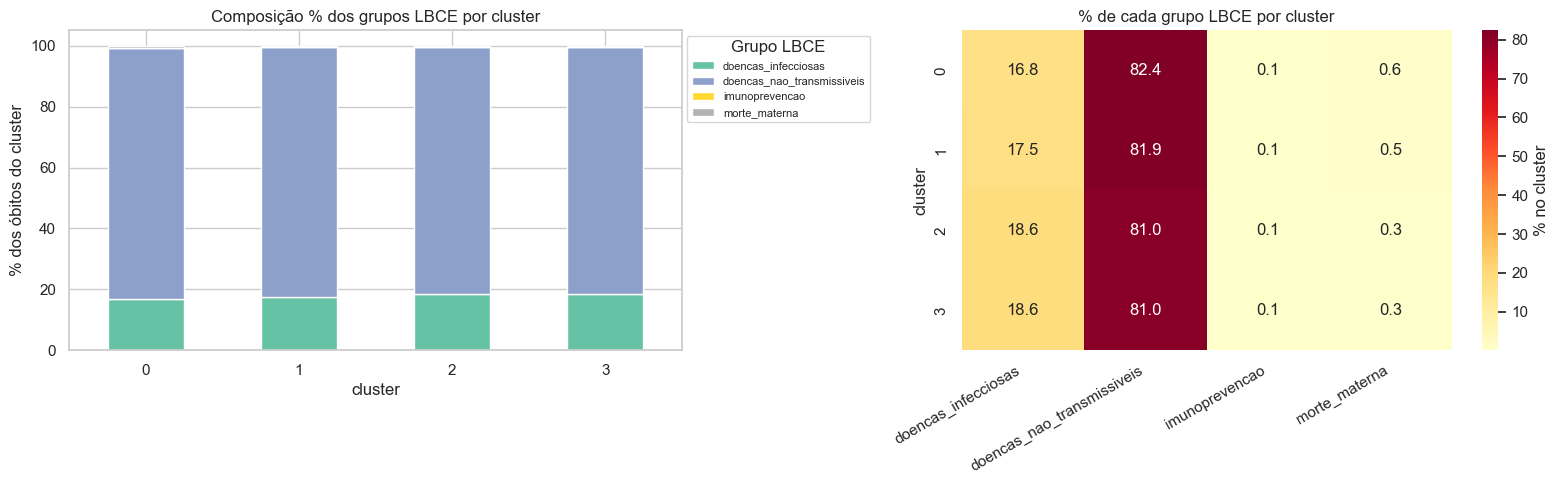

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lbce_pct.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2", edgecolor="white")
axes[0].set_title("Composição % dos grupos LBCE por cluster")
axes[0].set_xlabel("cluster"); axes[0].set_ylabel("% dos óbitos do cluster")
axes[0].legend(title="Grupo LBCE", bbox_to_anchor=(1.0, 1), loc="upper left", fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=0)

# Heatmap das proporções
sns.heatmap(lbce_pct.round(1), annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            cbar_kws={"label": "% no cluster"})
axes[1].set_title("% de cada grupo LBCE por cluster")
axes[1].set_xlabel(""); axes[1].set_ylabel("cluster")
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

plt.tight_layout(); plt.show()

## 5. Top causas CID-10 por cluster

Para cada cluster, as 15 causas básicas (categoria de 3 chars) mais frequentes, com a descrição textual. É o "do quê morre" literal.

In [8]:
TOP_N = 15
linhas_top = []

for c in CLUSTERS:
    sub = md[md["CLUSTER"] == c]
    total_c = len(sub)
    top = sub["CID_CAT3"].value_counts().head(TOP_N)
    print(f"\n{'='*78}\nCLUSTER {c}  —  {total_c:,} óbitos\n{'='*78}")
    for rank, (cat, n) in enumerate(top.items(), 1):
        descr = descrever(cat)
        pct = n / total_c * 100
        print(f"  {rank:>2}. {cat}  {pct:>5.1f}%  ({n:>6,})  {descr[:60]}")
        linhas_top.append({"CLUSTER": c, "rank": rank, "CID_CAT3": cat,
                            "descricao": descr, "n": n, "pct": round(pct, 2)})

top_causas_df = pd.DataFrame(linhas_top)


CLUSTER 0  —  68,538 óbitos
   1. I21   15.3%  (10,478)  Infarto agudo do miocardio
   2. E14    5.9%  ( 4,019)  Diabetes mellitus NE
   3. I64    5.3%  ( 3,631)  Acid vasc cerebr NE como hemorrag isquemico
   4. J18    4.8%  ( 3,304)  Pneumonia p/microorg NE
   5. I10    3.8%  ( 2,608)  Hipertensao essencial
   6. K70    3.4%  ( 2,300)  Doenc alcoolica do figado
   7. A41    3.1%  ( 2,139)  Outr septicemias
   8. I50    3.1%  ( 2,106)  Insuf cardiaca
   9. C34    3.1%  ( 2,105)  Neopl malig dos bronquios e dos pulmoes
  10. J44    3.0%  ( 2,080)  Outr doenc pulmonares obstrutivas cronicas
  11. E11    3.0%  ( 2,049)  Diabetes mellitus nao-insulino-dependemte
  12. F10    2.6%  ( 1,809)  Transt mentais comport dev uso alcool
  13. C16    2.5%  ( 1,734)  Neopl malig do estomago
  14. I61    2.4%  ( 1,643)  Hemorragia intracerebral
  15. C50    2.2%  ( 1,505)  Neopl malig da mama

CLUSTER 1  —  188,460 óbitos
   1. I21   13.9%  (26,144)  Infarto agudo do miocardio
   2. E14    6.7%  (12


CLUSTER 3  —  967,808 óbitos
   1. I21   12.5%  (120,543)  Infarto agudo do miocardio
   2. J18    5.4%  (51,788)  Pneumonia p/microorg NE
   3. E14    5.3%  (51,755)  Diabetes mellitus NE
   4. C34    4.7%  (45,844)  Neopl malig dos bronquios e dos pulmoes
   5. J44    4.3%  (41,707)  Outr doenc pulmonares obstrutivas cronicas
   6. C50    3.6%  (35,124)  Neopl malig da mama
   7. I10    3.1%  (29,869)  Hipertensao essencial
   8. I64    2.8%  (26,861)  Acid vasc cerebr NE como hemorrag isquemico
   9. I50    2.7%  (26,129)  Insuf cardiaca
  10. I25    2.7%  (25,867)  Doenc isquemica cronica do coracao
  11. A41    2.6%  (24,784)  Outr septicemias
  12. C18    2.5%  (24,130)  Neopl malig do colon
  13. I61    2.4%  (23,412)  Hemorragia intracerebral
  14. C16    2.2%  (20,808)  Neopl malig do estomago
  15. K70    2.1%  (20,182)  Doenc alcoolica do figado


## 6. Causas sobre-representadas por cluster (*lift*)

A causa mais *frequente* num cluster pode ser a mesma do país inteiro (ex.: infarto domina em todo lugar). Mais informativo é o **lift**: razão entre a participação da causa no cluster e sua participação nacional.

$$\text{lift}(causa, cluster) = \frac{P(causa \mid cluster)}{P(causa \mid Brasil)}$$

- lift **> 1** → a causa é *característica* daquele cluster (mais comum ali do que no país).
- lift **< 1** → a causa é sub-representada.

Filtramos causas com pelo menos 200 óbitos no cluster para evitar ruído de categorias raras.

In [9]:
# Participação nacional de cada causa
p_nacional = md["CID_CAT3"].value_counts(normalize=True)

MIN_OBITOS = 200
linhas_lift = []

for c in CLUSTERS:
    sub = md[md["CLUSTER"] == c]
    cont = sub["CID_CAT3"].value_counts()
    p_cluster = cont / len(sub)
    lift = (p_cluster / p_nacional).dropna()
    lift = lift[cont.reindex(lift.index) >= MIN_OBITOS]   # filtra raras
    top_lift = lift.sort_values(ascending=False).head(10)
    print(f"\n{'='*78}\nCLUSTER {c} — causas mais SOBRE-representadas (lift)\n{'='*78}")
    for cat, lv in top_lift.items():
        n = int(cont[cat])
        print(f"  lift {lv:>4.2f}×  {cat}  (n={n:>6,})  {descrever(cat)[:58]}")
        linhas_lift.append({"CLUSTER": c, "CID_CAT3": cat, "lift": round(lv, 3),
                            "n": n, "descricao": descrever(cat)})

lift_df = pd.DataFrame(linhas_lift)


CLUSTER 0 — causas mais SOBRE-representadas (lift)
  lift 1.64×  I64  (n= 3,631)  Acid vasc cerebr NE como hemorrag isquemico
  lift 1.62×  F10  (n= 1,809)  Transt mentais comport dev uso alcool
  lift 1.60×  E11  (n= 2,049)  Diabetes mellitus nao-insulino-dependemte
  lift 1.50×  B57  (n=   371)  Doenc de Chagas
  lift 1.48×  A09  (n=   321)  Diarreia e gastroenterite orig infecc presum
  lift 1.46×  K70  (n= 2,300)  Doenc alcoolica do figado
  lift 1.37×  G40  (n=   658)  Epilepsia
  lift 1.36×  C44  (n=   269)  Outr neopl malig da pele
  lift 1.31×  C53  (n= 1,200)  Neopl malig do colo do utero
  lift 1.19×  N18  (n=   837)  Insuf renal cronica

CLUSTER 1 — causas mais SOBRE-representadas (lift)
  lift 2.47×  B65  (n=   286)  Esquistossomose
  lift 1.66×  B57  (n= 1,125)  Doenc de Chagas
  lift 1.62×  F10  (n= 4,995)  Transt mentais comport dev uso alcool
  lift 1.47×  I64  (n= 8,959)  Acid vasc cerebr NE como hemorrag isquemico
  lift 1.46×  A04  (n=   326)  Outr infecc intestinai


CLUSTER 3 — causas mais SOBRE-representadas (lift)
  lift 1.21×  A39  (n=   205)  Infecc meningogocica
  lift 1.21×  I63  (n=14,564)  Infarto cerebral
  lift 1.17×  J40  (n=   237)  Bronquite NE como aguda ou cronica
  lift 1.17×  B18  (n= 2,190)  Hepatite viral cronica
  lift 1.17×  I25  (n=25,867)  Doenc isquemica cronica do coracao
  lift 1.15×  I70  (n=   719)  Aterosclerose
  lift 1.15×  C18  (n=24,130)  Neopl malig do colon
  lift 1.13×  E03  (n=   715)  Outr hipotireoidismos
  lift 1.13×  J10  (n=   910)  Influenza dev virus influenza identificado
  lift 1.13×  A17  (n=   252)  Tuberc do sist nervoso


## 7. Mineração de texto — vocabulário clínico distintivo por cluster

**Por que não TF-IDF puro?** As seções 4 e 5 revelaram que o *mix* de causas é muito parecido entre clusters — todos são dominados por infarto, diabetes e neoplasias. Um TF-IDF sobre a frequência bruta das descrições retornaria praticamente os mesmos termos (\"infarto\", \"diabetes\", \"neoplasia\") em todos os clusters, sem poder discriminante. O sinal socioeconômico não está em *quais* causas aparecem, mas em **quais estão sobre-representadas** (o *lift* da seção 6).

**Método — score de distintividade ponderado por lift.** Para cada cluster, somamos as palavras das descrições de causa, **ponderando cada causa pelo seu excesso de óbitos sobre o esperado nacional**:

$$\text{score}(termo, cluster) = \sum_{causa \,\ni\, termo} (\text{lift}_{causa} - 1) \times n_{causa,cluster} \quad\text{(só causas com lift} > 1)$$

Assim, palavras de causas características do cluster (lift alto) recebem peso grande; palavras de causas universais (lift ≈ 1) somam ≈ 0. O resultado é o vocabulário clínico que **distingue** cada perfil.

In [10]:
# Stopwords PT + termos clínicos genéricos / abreviações DATASUS sem valor discriminante
STOP = {
    "de", "da", "do", "das", "dos", "e", "a", "o", "as", "os", "em", "com", "sem",
    "por", "para", "na", "no", "nas", "nos", "ao", "aos", "que", "nao", "outras",
    "outros", "outro", "outra", "outr", "ne", "soe", "dev", "esp", "nce", "tipo",
    "parte", "partes", "como", "doenc", "localizacao", "localizada", "localiz",
    "forma", "formas", "alguma", "algumas", "sua", "durante", "apos", "mencao",
    "presum", "origem", "orig", "result",
}

def tokenizar(texto: str) -> list[str]:
    toks = re.findall(r"[a-zà-ú]+", texto.lower())
    return [t for t in toks if len(t) >= 4 and t not in STOP]

# Participação nacional (reutiliza p_nacional calculado na seção 6)
MIN_OBITOS_TERMO = 100
linhas_termos = []
score_por_cluster = {}

for c in CLUSTERS:
    sub  = md[md["CLUSTER"] == c]
    cont = sub["CID_CAT3"].value_counts()
    lift = (cont / len(sub) / p_nacional).dropna()
    lift = lift[cont.reindex(lift.index) >= MIN_OBITOS_TERMO]

    score = defaultdict(float)
    for cat, lv in lift.items():
        if lv > 1:                                   # só causas sobre-representadas
            excesso = (lv - 1) * cont[cat]           # excesso de óbitos sobre o esperado
            for tok in tokenizar(descrever(cat)):
                score[tok] += excesso
    score_por_cluster[c] = score
    for termo, sc in score.items():
        linhas_termos.append({"CLUSTER": c, "termo": termo, "score": round(sc, 1)})

termos_df = pd.DataFrame(linhas_termos)
print(f"Termos pontuados: {termos_df['termo'].nunique()} distintos em {len(CLUSTERS)} clusters")

Termos pontuados: 201 distintos em 4 clusters


In [11]:
TOP_TERMOS = 12

for c in CLUSTERS:
    top = sorted(score_por_cluster[c].items(), key=lambda x: -x[1])[:TOP_TERMOS]
    print(f"\nCLUSTER {c} — vocabulário distintivo (score lift-ponderado):")
    print("   " + "  ·  ".join(f"{t} ({s:,.0f})" for t, s in top))


CLUSTER 0 — vocabulário distintivo (score lift-ponderado):
   acid (2,313)  ·  vasc (2,313)  ·  cerebr (2,313)  ·  hemorrag (2,313)  ·  isquemico (2,313)  ·  infarto (2,010)  ·  agudo (2,010)  ·  miocardio (2,010)  ·  diabetes (1,613)  ·  mellitus (1,613)  ·  insulino (1,387)  ·  dependemte (1,226)

CLUSTER 1 — vocabulário distintivo (score lift-ponderado):
   diabetes (4,933)  ·  mellitus (4,933)  ·  acid (4,202)  ·  vasc (4,202)  ·  cerebr (4,202)  ·  hemorrag (4,202)  ·  isquemico (4,202)  ·  transt (3,113)  ·  mentais (3,113)  ·  comport (3,113)  ·  alcool (3,113)  ·  insulino (2,244)

CLUSTER 2 — vocabulário distintivo (score lift-ponderado):
   malig (1,287)  ·  neopl (1,227)  ·  hipertensao (970)  ·  essencial (970)  ·  pneumonia (794)  ·  microorg (735)  ·  pulmonares (721)  ·  obstrutivas (721)  ·  cronicas (721)  ·  septicemias (608)  ·  insuf (588)  ·  cardiaca (559)

CLUSTER 3 — vocabulário distintivo (score lift-ponderado):
   malig (12,467)  ·  neopl (12,114)  ·  cronica

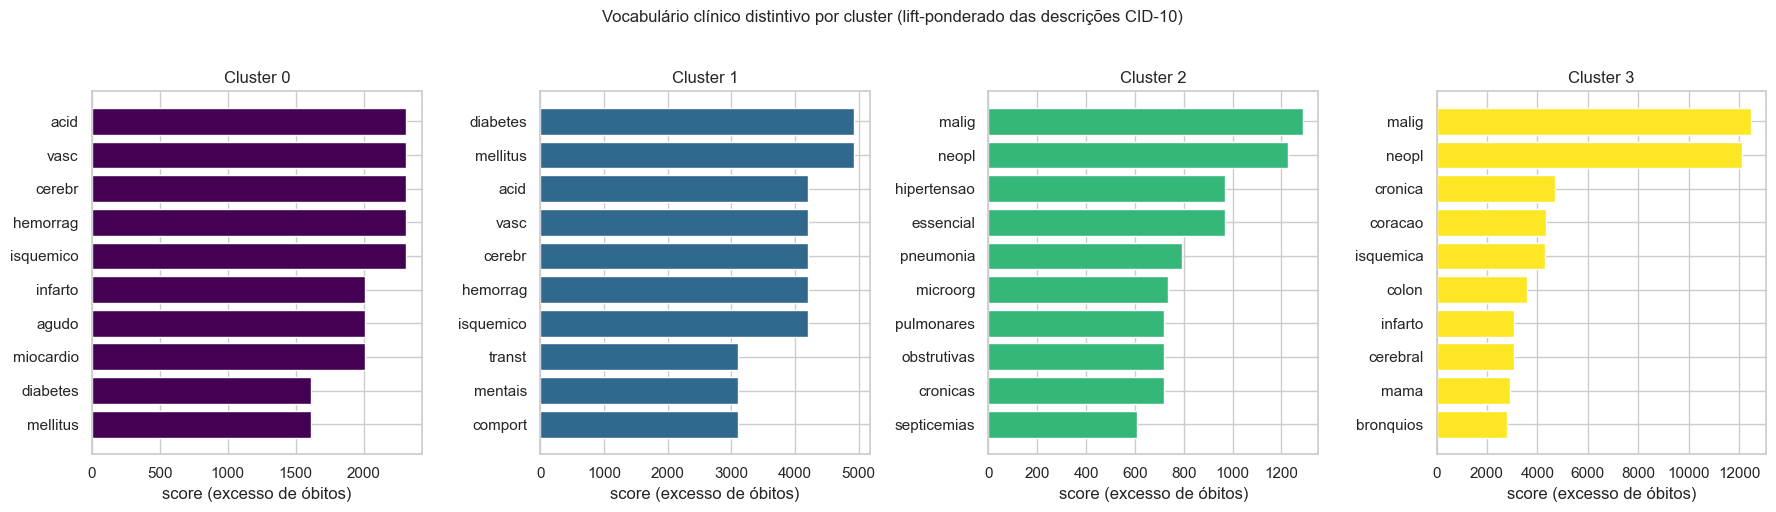

In [12]:
# Barras horizontais dos top termos distintivos por cluster
n_cl = len(CLUSTERS)
fig, axes = plt.subplots(1, n_cl, figsize=(4.5 * n_cl, 5))
if n_cl == 1:
    axes = [axes]
for i, (c, ax) in enumerate(zip(CLUSTERS, axes)):
    top = sorted(score_por_cluster[c].items(), key=lambda x: -x[1])[:10][::-1]
    termos_c = [t for t, _ in top]
    pesos_c  = [s for _, s in top]
    ax.barh(termos_c, pesos_c, color=plt.cm.viridis(i / max(n_cl - 1, 1)))
    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("score (excesso de óbitos)")
plt.suptitle("Vocabulário clínico distintivo por cluster (lift-ponderado das descrições CID-10)", y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

## 8. Persistência

In [13]:
out_top    = MODELS_DIR / "top_causas_cluster.csv"
out_lbce   = MODELS_DIR / "lbce_por_cluster.csv"
out_lift   = MODELS_DIR / "lift_causas_cluster.csv"
out_termos = MODELS_DIR / "termos_distintivos_cluster.csv"

top_causas_df.to_csv(out_top, index=False)
lbce_pct.round(2).to_csv(out_lbce)
lift_df.to_csv(out_lift, index=False)
termos_df.to_csv(out_termos, index=False)

for p in (out_top, out_lbce, out_lift, out_termos):
    print(f"  {p.name:<34} → {p.stat().st_size / 1e3:>6.1f} KB")

  top_causas_cluster.csv             →    2.9 KB
  lbce_por_cluster.csv               →    0.2 KB
  lift_causas_cluster.csv            →    1.8 KB
  termos_distintivos_cluster.csv     →    6.3 KB


---

**Como ler os resultados (ligação com a tese):**

- **Mix de causas é semelhante, a taxa é que difere.** As seções 4 e 5 mostram que todos os clusters são dominados por infarto, diabetes, pneumonia e neoplasias — a composição agregada da mortalidade evitável é parecida. O que distingue os perfis é a **intensidade** (taxa /100k, notebook 04), não a lista de causas em si.
- **O sinal socioeconômico está nas causas sobre-representadas (seção 6 — lift):** os clusters de menor desenvolvimento (0 e 1) sobre-indexam em **doenças infecciosas e negligenciadas da pobreza** — esquistossomose, doença de Chagas, diarreia/gastroenterite, transtornos por álcool e AVC; os clusters desenvolvidos (2 e 3) sobre-indexam em **condições crônicas/urbanas** — cardiopatia isquêmica crônica, neoplasias (cólon, esôfago, mama), enfisema, hipertensão. A **morte materna** também segue o gradiente esperado (mais alta nos clusters pobres).
- O **vocabulário distintivo (seção 7)** traduz esse contraste em termos clínicos, confirmando a leitura do lift de forma compacta.

**Conclusão:** a mortalidade evitável no Brasil tem uma **assinatura socioeconômica dupla** — perfis pobres ainda carregam doenças infecciosas que o desenvolvimento deveria ter eliminado, enquanto perfis ricos concentram as crônicas. Isso sustenta a tese de que reduzir a mortalidade evitável exige políticas diferenciadas por território.

**Ressalva metodológica:** o cluster é atribuído pelo *município de residência*, não pelo indivíduo. É uma análise ecológica — descreve o ambiente em que a pessoa vivia, não suas características individuais de renda/escolaridade (embora o microdado também as contenha, exploradas no `02b`).